<a href="https://colab.research.google.com/github/yananya012-svg/Students-habit-performance/blob/main/%20Student%20routine%20productivity%20project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 65.7 MB/s eta 0:00:00


2026-07-18 14:58:40.571 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-18 14:58:40.682 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-07-18 14:58:40.682 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-18 14:58:40.683 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-18 14:58:40.692 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-18 14:58:40.692 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-18 14:58:40.693 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-18 14:58:40.694 Thread 'MainThread': mi

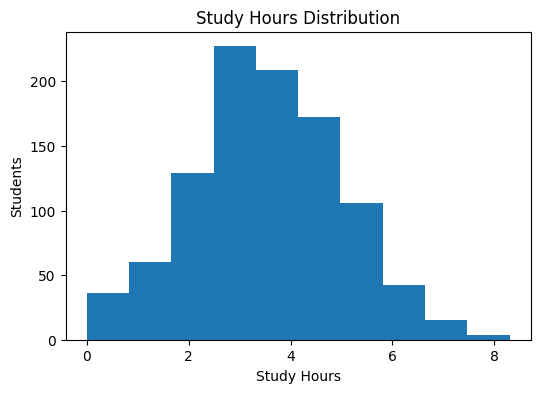

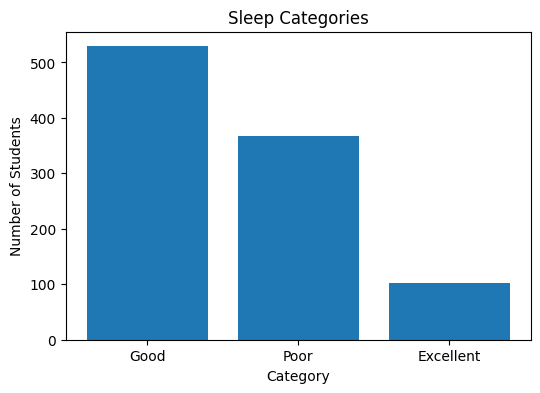

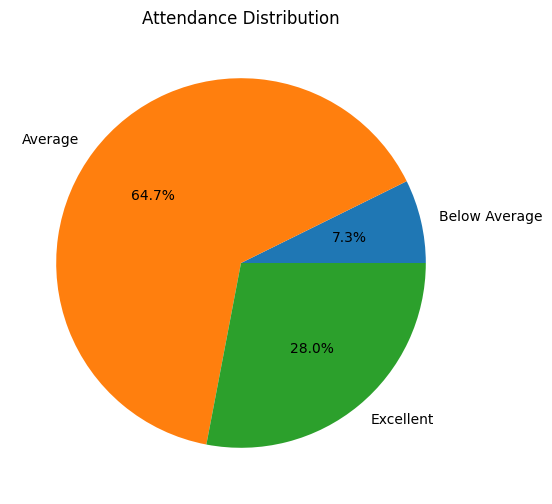

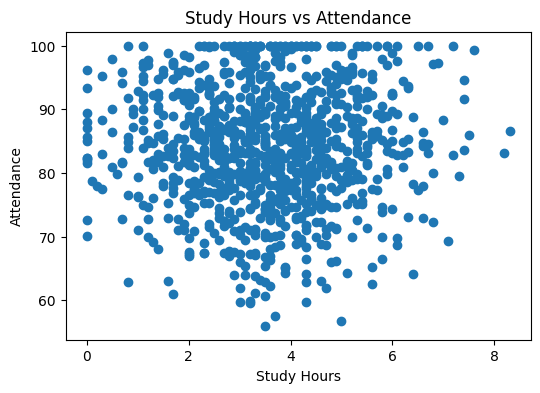

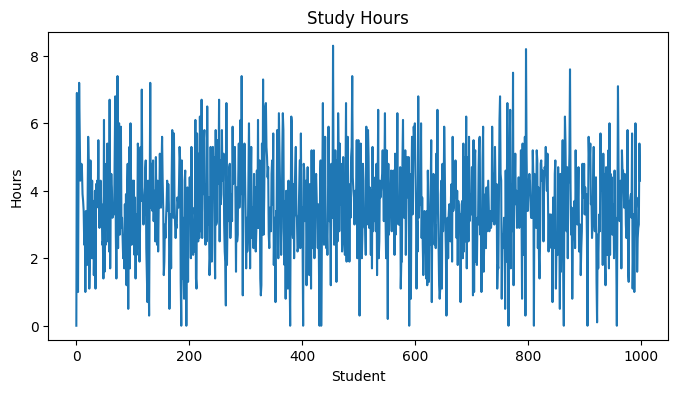

In [ ]:
!pip install streamlit
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

st.title("Student Habits Performance Analysis")

# Load dataset (CSV should be in the same folder as app.py)
df = pd.read_csv("student_habits_performance.csv")

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

st.write("Dataset Columns:", df.columns.tolist())

# Basic Information
st.write(df.head())
st.write(df.describe())
st.write(df.isnull().sum())

# Handle missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Create Productivity Score
df["Productivity Score"] = (
    df["study_hours_per_day"] * 5
    + df["attendance_percentage"] * 0.3
    - df["social_media_hours"] * 2
)

# Avoid division by zero
df["Study Efficiency"] = (
    df["study_hours_per_day"] /
    df["social_media_hours"].replace(0, np.nan)
)

# Create Sleep Category
df["Sleep Category"] = pd.cut(
    df["sleep_hours"],
    bins=[0, 6, 8, 12],
    labels=["Poor", "Good", "Excellent"],
    include_lowest=True
)

# Statistics
st.subheader("Statistics")
st.write("Average Study Hours:", df["study_hours_per_day"].mean())
st.write("Maximum Study Hours:", df["study_hours_per_day"].max())
st.write("Minimum Study Hours:", df["study_hours_per_day"].min())
st.write("Average Sleep Hours:", df["sleep_hours"].mean())
st.write("Average Social Media Hours:", df["social_media_hours"].mean())
st.write("Average Attendance:", df["attendance_percentage"].mean())

# Histogram
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(df["study_hours_per_day"], bins=10)
ax.set_title("Study Hours Distribution")
ax.set_xlabel("Study Hours")
ax.set_ylabel("Students")
st.pyplot(fig)

# Sleep Category Bar Chart
sleep = df["Sleep Category"].value_counts()

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(sleep.index.astype(str), sleep.values)
ax.set_title("Sleep Categories")
ax.set_xlabel("Category")
ax.set_ylabel("Number of Students")
st.pyplot(fig)

# Attendance Pie Chart
attendance = df["attendance_percentage"]

labels = ["Below Average", "Average", "Excellent"]

sizes = [
    len(attendance[attendance < 70]),
    len(attendance[(attendance >= 70) & (attendance < 90)]),
    len(attendance[attendance >= 90])
]

fig, ax = plt.subplots(figsize=(6,6))
ax.pie(sizes, labels=labels, autopct="%1.1f%%")
ax.set_title("Attendance Distribution")
st.pyplot(fig)

# Scatter Plot
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(df["study_hours_per_day"], df["attendance_percentage"])
ax.set_xlabel("Study Hours")
ax.set_ylabel("Attendance")
ax.set_title("Study Hours vs Attendance")
st.pyplot(fig)

# Line Plot
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(df["study_hours_per_day"])
ax.set_title("Study Hours")
ax.set_xlabel("Student")
ax.set_ylabel("Hours")
st.pyplot(fig)

# Save processed data
df.to_csv("Processed_Student_Productivity.csv", index=False)

# Summary
st.subheader("Project Summary")
st.write("Total Students:", len(df))
st.write("Average Study Hours:", df["study_hours_per_day"].mean())
st.write("Average Sleep Hours:", df["sleep_hours"].mean())
st.write("Average Attendance:", df["attendance_percentage"].mean())
st.write("Highest Productivity Score:", df["Productivity Score"].max())